RDD on CN data

# Data sources

From x.com we download the raw data (including notes-00000.tsv)

On HPC we apply the scoring algorithsms, generating output in parquet format

We preprocess and merge these files using

    preprocess_dates.py
    merge_ratings_with_notes.py

# Environment

see requirements.txt or communitynotes2025-05-09.yml

# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
import calendar
from sklearn import linear_model
import statsmodels.api as sm
import statsmodels.formula.api as smf
import fastparquet



# TODO

add data prep instructions

## RDD

**Research question(s)**: Is it a problem that such a low proportion of notes are rated as helpful ? Restated, at the individual level: Does having a note rated as helpful encourage future contributions, and conversely, does not having a note rated as helpful discourage future contributions. Our unit of analysis is the individuals in the CN system: how are they affected by what happens to their notes?

**Design**: regression discontinuity, comparing notes around threshold for being rated helpful

**Candidate set**: all first-time note authors (yes, most notes might be authored by a minority of repeat authors, but these people are already committed to CN and/or are the people least likely to be influenced by note success, *and* I think the effect on people who have just jointed CN is the one we are most interested in). We will look at the first note of first time note authors only.

(option: we could just look at the first note of 2024, rather than of all time)

**Outcome measure**: does the first time note author go on to author another note? (ie in the rest of 2024).

**Predictors**: there is this issue of notes flip-flopping between helpful and unhelpful. After two weeks a note's status is fixed, and a note author receives notifications each time the note status changes. To create a tractable analysis, consider these two simplifications

A. Final outcome: either Helpful (1) or Unhelpful (0), ignoring all prior status history. We compare notes whose final score was just above and below threshold for this. Call this H

B. Notification occurrence : note author received a notification that the note was rated helpful (1), or never did (0). We compare notes whose maximum all time score was just above or below threshold for this. Call this N

Note that the two predictors define two, distinct, subsets of the candidates (ie you can't just throw both predictors into the same regression, since authors who have a relevant score for H may not have a value for N, and vice versa)

In [2]:
# First let's inmport the data anbd count how many notes we have

# Tom thinkpad location
# rated = pd.read_parquet('/home/tomstafford/Desktop/communitynotes/data2025post/' + 'rated_notes_compact.parquet', engine='auto')

# Tom laptop location
#rated = pd.read_parquet('/home/tom/Desktop/communitynotes/data2025post/' + 'rated_notes_compact.parquet', engine='auto')

rated = pd.read_parquet('./data2026post/' + 'rated_notes_compact.parquet', engine='auto')

len(rated) #1,946,619 for 2025 data


3173276

In [3]:
# For RDD we need to remove the notes which don't have enough rating to be helpful
rated['rating_group'] = np.where(rated['numRatings'] >= 5,
                                        1, 0)

rated[rated['rating_group'] == 1]['decidedBy'].value_counts(normalize=True)

decidedBy
CoreModel (v1.1)                      0.679272
CoreWithTopicsModel (v1.1)            0.117103
ExpansionModel (v1.1)                 0.055700
ScoringDriftGuard (v1.0)              0.050543
ExpansionPlusModel (v1.1)             0.028802
MultiGroupModel01 (v1.0)              0.027485
NmrDueToMinStableCrhTime (v1.0)       0.023368
GaussianModel (v1.0)                  0.009416
GaussianCoreWithTopicsModel (v1.0)    0.002285
TopicModel02 (v1.0)                   0.001033
TopicModel01 (v1.0)                   0.000989
GroupModel03 (v1.1)                   0.000803
GroupModel18NMR (v1.1)                0.000574
GroupModel33NMR (v1.1)                0.000534
GroupModel01 (v1.1)                   0.000462
TopicModel04 (v1.0)                   0.000397
GroupModel13 (v1.1)                   0.000393
GroupModel09 (v1.1)                   0.000214
GroupModel06 (v1.1)                   0.000169
InsufficientExplanation (v1.0)        0.000129
GroupModel14 (v1.1)                   0.000079
Gro

In [4]:
# note intercepts are:
# 'coreNoteIntercept', 'expansionNoteIntercept', 'coverageNoteIntercept',
#        'groupNoteIntercept', 'expansionPlusNoteIntercept',
#        'topicNoteIntercept', 'multiGroupNoteIntercept',
#        'coreWithTopicsNoteIntercept', 'gaussianNoteIntercept',
#        'gaussianCoreWithTopicsNoteIntercept'

In [5]:
# sanity check of our data

# numeber of non-na rows 
rated['createdAt'].count()

np.int64(2788669)

In [6]:
# Restricting our analysis to notes after 2024
rated_2024 = rated[(rated.createdAt >= pd.Timestamp(2024, 1, 1)) &
                    (rated.createdAt <= pd.Timestamp(2026, 6, 1))]
# cap our data 
rated = rated[(rated.createdAt <= pd.Timestamp(2026, 6, 1))]
# Find the first note written by each author, and if that author goes on to write another note
first_notes = rated.groupby('noteAuthorParticipantId')\
    [['createdAt', 'finalRatingStatus', 'numRatings', 'rating_group',
     'decidedBy','coreNoteFactor1', 'coreNoteIntercept', 'coreNoteInterceptMax',
     'expansionNoteFactor1', 'expansionNoteIntercept', 'expansionNoteInterceptMax',
     'coreWithTopicsNoteFactor1', 'coreWithTopicsNoteIntercept', 'coreWithTopicsNoteInterceptMax',
      'classification']]\
    .first().reset_index()
# Restricting our analysis to authors who joined in 2024 or 2025 
first_notes = first_notes[(first_notes.createdAt >= pd.Timestamp(2024, 1, 1)) &
                          (first_notes.createdAt < pd.Timestamp(2026, 1, 1))]
have_another_note = rated_2024[rated_2024.groupby('noteAuthorParticipantId').cumcount() >= 2]\
    ['noteAuthorParticipantId'].to_list()
first_notes['if_written_again'] = first_notes['noteAuthorParticipantId'].isin(have_another_note)
first_notes = first_notes[first_notes['decidedBy']\
    .isin(['CoreModel (v1.1)', 'ExpansionModel (v1.1)', 'CoreWithTopicsModel (v1.1)'])]
# first_notes = first_notes[first_notes['decidedBy'].isin(['CoreModel (v1.1)'])]
# remove NNNs
first_notes = first_notes[first_notes['classification'] != 'NOT_MISLEADING']


In [7]:
# a function to map decidedBy to intercept
def model_to_column(s):
    base = s.split("Model")[0]
    return base[:1].lower() + base[1:] + "NoteIntercept"

cols = first_notes["decidedBy"].apply(model_to_column)

first_notes["intercept"] = first_notes.to_numpy()[
np.arange(len(first_notes)),
first_notes.columns.get_indexer(cols)
]

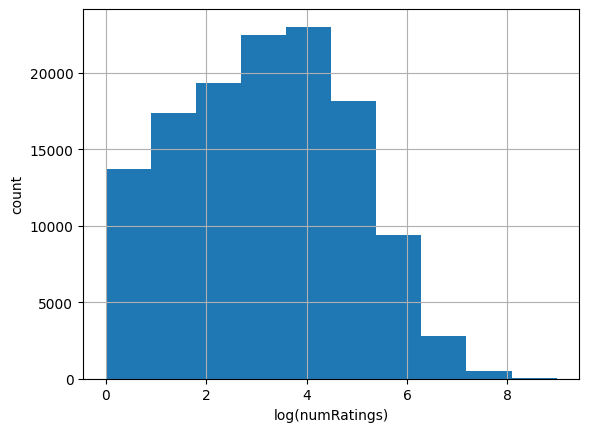

In [8]:
# Most notes have a small number of rating, a small number have very many ratinhgs
# This means the distribution of ratings is very skewed.
# We take the log of the number of ratings to make the distribution more normal


first_notes['log_numRatings']=np.log(first_notes['numRatings'])
# some don't even have 1 rating
first_notes[first_notes['numRatings'] > 0]['log_numRatings'].hist() #normal
plt.xlabel('log(numRatings)')
plt.ylabel('count')
plt.show()



In [9]:
first_notes['finalRatingStatus'].value_counts()

finalRatingStatus
NEEDS_MORE_RATINGS             110039
CURRENTLY_RATED_HELPFUL         12109
CURRENTLY_RATED_NOT_HELPFUL      4671
Name: count, dtype: int64

In [10]:
rated.createdAt.min()

Timestamp('2021-01-28 00:27:47.892000')

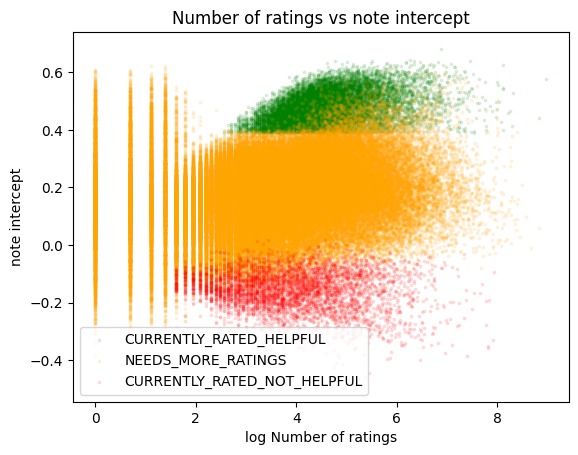

In [11]:
# Plotting log(numRatings) vs NoteInterceptMax, with colours according to Note final statuys (finalRatingStatus )  
plt.clf()
groups = ['CURRENTLY_RATED_HELPFUL','NEEDS_MORE_RATINGS','CURRENTLY_RATED_NOT_HELPFUL']
colours=['green','orange','red']

ms=3;alphaval=0.1;


for i in range(3):
    plt.scatter(first_notes[first_notes['finalRatingStatus']==groups[i]]['log_numRatings'], first_notes[first_notes['finalRatingStatus']==groups[i]]['intercept'], s = ms,alpha=alphaval,color=colours[i],label=groups[i])  
    # j+=1

plt.xlabel('log Number of ratings')
plt.ylabel('note intercept')
plt.title('Number of ratings vs note intercept')
plt.legend(loc=0)
plt.savefig('scatter_numRatings_NoteIntercept.png',dpi=120,bbox_inches='tight')
plt.show()

#TODO make the legend markers bigger and clearer

# Intepretation:

There is a discontinuity: although some notes labelled NEEDS_MORE_RATINGS have a score above 0.4, no notes with a score below 0.4 have a label CURERENTLY_RATED_HELPFUL

This establishes the logic required for our analaysis

# Now, the RDD

In [12]:
first_notes.head(20)

,noteAuthorParticipantId,createdAt,finalRatingStatus,numRatings,rating_group,decidedBy,coreNoteFactor1,coreNoteIntercept,coreNoteInterceptMax,expansionNoteFactor1,expansionNoteIntercept,expansionNoteInterceptMax,coreWithTopicsNoteFactor1,coreWithTopicsNoteIntercept,coreWithTopicsNoteInterceptMax,classification,if_written_again,intercept,log_numRatings
0,000011269AD6F327AED0F4086A732B4052F9D28E8791E1...,2025-12-07 20:55:12.699,NEEDS_MORE_RATINGS,12,1,CoreModel (v1.1),-0.437952,0.114140,0.223308,-0.480769,0.112043,NaN,-0.482230,0.106791,0.241849,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,0.11414,2.484907
4,0000D09E403B665ADB698D8DF843CB22F352EF89ABF7CB...,2025-01-17 12:09:09.668,NEEDS_MORE_RATINGS,1,0,CoreModel (v1.1),-0.444056,0.082387,0.174391,-0.445751,0.077217,NaN,-0.452347,0.082006,0.182738,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,0.082387,0.000000
11,000296D74E8D180E81994B7BD44CB2F98DE6C0BF0C5EAC...,2025-01-10 10:19:20.046,CURRENTLY_RATED_HELPFUL,173,1,CoreModel (v1.1),0.267467,0.395177,0.412596,0.234272,0.390558,NaN,0.227647,0.427095,0.445194,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,0.395177,5.153292
14,0002DF4EC6D6BD71CB266B641684F34AB9133091E7C54A...,2025-06-26 04:03:06.009,NEEDS_MORE_RATINGS,7,1,CoreModel (v1.1),-0.144881,0.209105,0.294341,-0.136778,0.203673,NaN,-0.147749,0.216478,0.306854,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,0.209105,1.945910
15,000304B792000A2283133C9E2EBC94CC609C308CE68611...,2024-11-23 14:56:11.849,CURRENTLY_RATED_NOT_HELPFUL,9,1,CoreModel (v1.1),0.034284,-0.186664,-0.086627,0.028915,-0.202121,NaN,0.033005,-0.204795,-0.094194,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,-0.186664,2.197225
21,00039991A9322D52F83399BC5B951F43B2A73869C21F10...,2025-03-09 22:26:16.635,NEEDS_MORE_RATINGS,52,1,CoreModel (v1.1),-0.407104,-0.054636,-0.001684,-0.575608,0.011614,NaN,-0.588538,0.008341,0.061545,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,-0.054636,3.951244
24,000415A1E3D1DA95BD626E1D938E4A9AFFB446D1A7D532...,2024-05-02 12:48:23.059,NEEDS_MORE_RATINGS,10,1,CoreModel (v1.1),0.421199,0.039378,0.140859,0.458872,0.079944,NaN,0.397759,0.049893,0.164020,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,0.039378,2.302585
26,00044FB2DED19DC928F99A40FEC1EDD37DC413018A6341...,2025-04-01 15:18:17.154,NEEDS_MORE_RATINGS,72,1,CoreModel (v1.1),0.109640,0.166866,0.235057,-0.095533,0.169006,NaN,-0.090791,0.115357,0.211506,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,0.166866,4.276666
28,00054DA8CA53842EE3042D2E203830D7F023E91EC47259...,2025-01-13 16:08:31.726,CURRENTLY_RATED_HELPFUL,73,1,CoreModel (v1.1),-0.048334,0.453889,0.481544,-0.047195,0.454572,NaN,-0.025763,0.453829,0.478230,MISINFORMED_OR_POTENTIALLY_MISLEADING,True,0.453889,4.290459
29,00055253971F408A7AB80D461A543E010EC67DFAF29C45...,2024-02-05 08:22:29.333,NEEDS_MORE_RATINGS,38,1,CoreModel (v1.1),-0.607414,0.168714,0.303777,-0.632944,0.170598,NaN,-0.657375,0.138514,0.291674,MISINFORMED_OR_POTENTIALLY_MISLEADING,False,0.168714,3.637586


In [13]:
# prepare the common vars for all models
# RDD 
cutoff = 0.4 #threshold at which a note is rated as helpful
bandwidth = 0.1 #window around cutoff
# keep only notes with enough rating
first_notes = first_notes[first_notes['rating_group'] == 1]

Now the models with all data:

In [14]:
# all notes
# most recent score

running_variable = first_notes['intercept']
is_na_mask = first_notes['intercept'].isna()
# Treatment = 1 if running_variable >= cutoff, else 0
treatment = np.where(running_variable >= cutoff, 1, 0)

#
outcome_variable = first_notes['if_written_again'].astype(int) # y value, binary output

# we can restrict the analysis to a window (bandwidth) around the cutoff.

mask = (running_variable > cutoff - bandwidth)  & (running_variable < cutoff + bandwidth)

data = pd.DataFrame({
    'running_variable': running_variable[mask & ~is_na_mask],
    'treatment': treatment[mask & ~is_na_mask],
    'outcome_variable': outcome_variable[mask & ~is_na_mask]
})

# Center the running variable at the cutoff for easier interpretation of the intercept
data['running_variable_centered'] = data['running_variable'] - cutoff
data = data.astype({'running_variable_centered': float})
print("All data, current score")
print(f"\nNumber of treated units: {data['treatment'].sum()}")
print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# original
rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()

# The coefficient for 'treatment' is the estimated effect at the cutoff.
estimated_effect = rdd_model.params['treatment']
print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

print("I think we can intepret this as a % change the chance of authoring again if published")

p_value_treatment = rdd_model.pvalues['treatment']
t_statistic_treatment = rdd_model.tvalues['treatment']

# print out p value and t-statistic for treatment
print(f"\nP-value for treatment: {p_value_treatment:.4f}")
print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")



All data, current score

Number of treated units: 8700
Number of control units: 10792

Estimated Treatment Effect at the Cutoff: 0.0368
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.0158
T-statistic for treatment: 2.4133


Models with aligned notes (thier current score with locked status)

In [15]:
# only aligned notes 

running_variable = first_notes['intercept']
is_na_mask = first_notes['intercept'].isna()
# # add note factor
# factor = np.where(
#     first_notes["decidedBy"] == "CoreModel (v1.1)",
#     first_notes["coreNoteFactor1"],
#     first_notes["expansionNoteFactor1"]
# )
# first_notes['factor'] = factor

# Treatment = 1 if running_variable >= cutoff, else 0
treatment = np.where(running_variable >= cutoff, 1, 0)
outcome_variable = first_notes['if_written_again'].astype(int)
# keep when intercept and locked status align
# keep when intercept and locked status align & factor is less than .5
# mask_alignment = (((first_notes["intercept"] > cutoff) & 
# (first_notes["finalRatingStatus"] == "CURRENTLY_RATED_HELPFUL") &
# (abs(first_notes["factor"]) < .5)) |
#     ((first_notes["intercept"] < cutoff) & (first_notes["finalRatingStatus"] != "CURRENTLY_RATED_HELPFUL")))
mask_alignment = (((first_notes["intercept"] > cutoff) & (first_notes["finalRatingStatus"] == "CURRENTLY_RATED_HELPFUL")) |
    ((first_notes["intercept"] < cutoff) & (first_notes["finalRatingStatus"] != "CURRENTLY_RATED_HELPFUL")))

mask = (running_variable > cutoff - bandwidth)  & (running_variable < cutoff + bandwidth)
data = pd.DataFrame({
    'running_variable': running_variable[mask & mask_alignment & ~is_na_mask],
    'treatment': treatment[mask & mask_alignment & ~is_na_mask],
    'outcome_variable': outcome_variable[mask & mask_alignment & ~is_na_mask]
})

# Center the running variable at the cutoff for easier interpretation of the intercept
data['running_variable_centered'] = data['running_variable'] - cutoff
data = data.astype({'running_variable_centered': float})
print(f"\nAligned data, current score")
print(f"\nNumber of treated units: {data['treatment'].sum()}")
print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# original
rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()
# The coefficient for 'treatment' is the estimated effect at the cutoff.
estimated_effect = rdd_model.params['treatment']
print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

print("I think we can intepret this as a % change the chance of authoring again if published")

p_value_treatment = rdd_model.pvalues['treatment']
t_statistic_treatment = rdd_model.tvalues['treatment']

# print out p value and t-statistic for treatment
print(f"\nP-value for treatment: {p_value_treatment:.4f}")
print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")


Aligned data, current score

Number of treated units: 7343
Number of control units: 10242

Estimated Treatment Effect at the Cutoff: 0.0638
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.0002
T-statistic for treatment: 3.7077


In [ ]:
# # only aligned notes with max score
# running_variable_max = np.where(
#     first_notes["decidedBy"] == "CoreModel (v1.1)",
#     first_notes["coreNoteInterceptMax"],
#     first_notes["expansionNoteInterceptMax"]
# ) # x value, continuous input

# first_notes['intercept'] = running_variable_max
# # keep when intercept and locked status align
# # Treatment = 1 if running_variable >= cutoff, else 0
# treatment = np.where(running_variable_max >= cutoff, 1, 0)
# outcome_variable = first_notes['if_written_again'].astype(int)

# mask_alignment = (((first_notes["intercept"] > cutoff) & (first_notes["finalRatingStatus"] == "CURRENTLY_RATED_HELPFUL")) |
#     ((first_notes["intercept"] < cutoff) & (first_notes["finalRatingStatus"] != "CURRENTLY_RATED_HELPFUL")))
# mask = (running_variable_max > cutoff - bandwidth)  & (running_variable_max < cutoff + bandwidth)
# data = pd.DataFrame({
#     'running_variable': running_variable_max[mask & mask_alignment],
#     'treatment': treatment[mask & mask_alignment],
#     'outcome_variable': outcome_variable[mask & mask_alignment]
# })

# # Center the running variable at the cutoff for easier interpretation of the intercept
# data['running_variable_centered'] = data['running_variable'] - cutoff
# print(f"\nAligned data, max score")
# print(f"\nNumber of treated units: {data['treatment'].sum()}")
# print(f"Number of control units: {data['treatment'].count() - data['treatment'].sum()}")
# # original
# rdd_model_formula = 'outcome_variable ~ running_variable_centered * treatment'

# rdd_model = smf.ols(formula=rdd_model_formula, data=data).fit()
# # The coefficient for 'treatment' is the estimated effect at the cutoff.
# estimated_effect = rdd_model.params['treatment']
# print(f"\nEstimated Treatment Effect at the Cutoff: {estimated_effect:.4f}")

# print("I think we can intepret this as a % change the chance of authoring again if published")

# p_value_treatment = rdd_model.pvalues['treatment']
# t_statistic_treatment = rdd_model.tvalues['treatment']

# # print out p value and t-statistic for treatment
# print(f"\nP-value for treatment: {p_value_treatment:.4f}")
# print(f"T-statistic for treatment: {t_statistic_treatment:.4f}")



Aligned data, max score

Number of treated units: 8936
Number of control units: 53137

Estimated Treatment Effect at the Cutoff: 0.0360
I think we can intepret this as a % change the chance of authoring again if published

P-value for treatment: 0.0084
T-statistic for treatment: 2.6354


In [ ]:
## if you want to see the full model output run this
# print(rdd_model.summary())